# Proyecto 2 — Ingeniería de Variables y Partición de Datos

## Reto #11: Predicción de compradores recurrentes

**CC3084 – Data Science | Universidad del Valle de Guatemala | Semestre II – 2026**

---

Este notebook corresponde al **paso 3** de la fase de resultados. A partir del registro de actividad (`user_log_format1.csv`, 54.9 millones de filas) se construyen las variables que usarán los modelos, en cuatro niveles:

1. **Par usuario-vendedor** (`p_`): comportamiento del usuario con el vendedor, separando la actividad del Double 11 de la actividad previa.
2. **Usuario** (`u_`): comportamiento del usuario en toda la plataforma.
3. **Vendedor** (`m_`): tamaño, conversión y fidelidad de la clientela del vendedor.
4. **Relación** (`x_`): qué tan concentrada está la actividad del usuario en el vendedor.

Además se agregan las variables demográficas y se define la **partición entrenamiento/prueba** (80/20, estratificada por `label` y agrupada por `user_id`) y los **5 pliegues de validación cruzada** del conjunto de entrenamiento.

**Control de fuga**: ninguna variable de este notebook usa `label`. La tasa de recompra del vendedor (*target encoding*) se calcula en el notebook de modelado, fuera de pliegue.

## 1. Configuración

In [1]:
from pathlib import Path
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)


def _find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'data' / 'data_format1').exists():
            return candidate
    return current


PROJECT_ROOT = _find_project_root()
DATA_DIR = PROJECT_ROOT / 'data' / 'data_format1'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR = PROJECT_ROOT / 'outputs' / 'figures'
TAB_DIR = PROJECT_ROOT / 'outputs' / 'tables'
for d in (PROCESSED_DIR, FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / 'train_format1.csv'
TEST_PATH = DATA_DIR / 'test_format1.csv'
USER_INFO_PATH = DATA_DIR / 'user_info_format1.csv'
USER_LOG_PATH = DATA_DIR / 'user_log_format1.csv'
LOG_PARQUET = PROCESSED_DIR / 'user_log.parquet'

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
                     'font.size': 11, 'axes.titlesize': 13})
sns.set_style('whitegrid')
PALETTE = sns.color_palette('Set2')

print(f'Raíz del proyecto: {PROJECT_ROOT}')

Raíz del proyecto: C:\Users\Gabriel\Documents\Universidad\semestre8\data\proyecto2\DS-Proyecto2


## 2. Carga de datos

El registro de actividad completo ocupa ~1 GB en memoria con tipos compactos (`int8`, `int16`, `int32`), por lo que se carga completo. La primera ejecución lo convierte a **parquet** (`data/processed/user_log.parquet`); las siguientes lo leen en segundos.

> Requisito: ~8 GB de RAM libres para este notebook.

In [2]:
LOG_DTYPE = {
    'user_id': 'int32', 'item_id': 'int32', 'cat_id': 'int16', 'seller_id': 'int16',
    'brand_id': 'float32', 'time_stamp': 'int16', 'action_type': 'int8',
}

t0 = time.time()
if LOG_PARQUET.exists():
    log = pd.read_parquet(LOG_PARQUET)
    origen = 'parquet'
else:
    log = pd.read_csv(USER_LOG_PATH, engine='pyarrow', dtype=LOG_DTYPE)
    log.to_parquet(LOG_PARQUET, index=False)
    origen = 'CSV (se guardó copia en parquet)'

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH).drop(columns='prob')
user_info = pd.read_csv(USER_INFO_PATH)

print(f'user_log cargado desde {origen} en {time.time() - t0:.1f} s')
print(f'  {len(log):,} filas | {log.memory_usage().sum() / 1e9:.2f} GB en memoria')
print(f'train: {len(train):,} pares | test (competencia): {len(test):,} pares | user_info: {len(user_info):,}')

user_log cargado desde parquet en 0.6 s
  54,925,330 filas | 1.04 GB en memoria
train: 260,864 pares | test (competencia): 261,477 pares | user_info: 424,170


## 3. Variables temporales e indicadores

`time_stamp` está en formato MMDD sin año. Se convierte a **días antes del Double 11** (`dias_antes_d11`: 0 = 11 de noviembre, 1 = 10 de noviembre, …) usando un año de referencia no bisiesto; solo importan las diferencias entre fechas, no el año.

Se crean indicadores por fila para cada tipo de acción y para el periodo (Double 11 o antes).

In [3]:
ts_unicos = np.sort(log['time_stamp'].unique())
dia_del_anio = pd.to_datetime(
    '2015' + pd.Series(ts_unicos).astype(str).str.zfill(4), format='%Y%m%d'
).dt.dayofyear.to_numpy()
D11 = int(dia_del_anio[ts_unicos == 1111][0])

lut = np.zeros(ts_unicos.max() + 1, dtype=np.int16)
lut[ts_unicos] = D11 - dia_del_anio
log['dias_antes_d11'] = lut[log['time_stamp'].to_numpy()]

log['click'] = (log['action_type'] == 0).astype('int8')
log['cart'] = (log['action_type'] == 1).astype('int8')
log['buy'] = (log['action_type'] == 2).astype('int8')
log['fav'] = (log['action_type'] == 3).astype('int8')
log['d11'] = (log['time_stamp'] == 1111).astype('int8')
log['pre'] = (log['time_stamp'] < 1111).astype('int8')

print(f"Rango de dias_antes_d11: {log['dias_antes_d11'].min()} a {log['dias_antes_d11'].max()}")
print(f"Filas del Double 11: {log['d11'].sum():,} | filas previas: {log['pre'].sum():,} | "
      f"filas posteriores (12/11): {(log['time_stamp'] > 1111).sum():,}")

Rango de dias_antes_d11: -1 a 184
Filas del Double 11: 10,582,633 | filas previas: 44,342,651 | filas posteriores (12/11): 46


### 3.1 Verificación de la definición del problema

Según la competencia, cada par de entrenamiento es un **comprador nuevo** del Double 11: su primera compra al vendedor ocurre el 11 de noviembre. Se verifica en los datos, y se revisa que la actividad del 12 de noviembre (posterior al evento) no filtre información de la etiqueta.

In [4]:
def pair_key(user, seller):
    """Llave entera única del par (seller_id < 10,000)."""
    return user.astype('int64') * 10_000 + seller.astype('int64')


log['pair_key'] = pair_key(log['user_id'], log['seller_id'])
train['pair_key'] = pair_key(train['user_id'], train['merchant_id'])
test['pair_key'] = pair_key(test['user_id'], test['merchant_id'])

compras_train = log[(log['buy'] == 1) & log['pair_key'].isin(train['pair_key'])]
primera_compra = compras_train.groupby('pair_key')['time_stamp'].min()

print("Primera compra de cada par de entrenamiento:")
print(primera_compra.value_counts().to_string())
print(f"\nPares con compras antes del 11/11: {compras_train.loc[compras_train['pre'] == 1, 'pair_key'].nunique()}")
print(f"Pares con compras el 12/11:         {compras_train.loc[compras_train['time_stamp'] == 1112, 'pair_key'].nunique()}")
print(f"Filas del 12/11 en todo el log:     {(log['time_stamp'] == 1112).sum()}")

Primera compra de cada par de entrenamiento:
time_stamp
1111    260864

Pares con compras antes del 11/11: 0
Pares con compras el 12/11:         0
Filas del 12/11 en todo el log:     46


**Interpretación**: el 100 % de los pares de entrenamiento compró por primera vez al vendedor el 11 de noviembre y ninguno le había comprado antes, lo que confirma la definición de "comprador nuevo del Double 11". El 12 de noviembre solo tiene 46 filas y ninguna es una compra de un par de entrenamiento, por lo que no hay fuga de la etiqueta. Por esta misma definición, `p_purchase` cuenta compras del Double 11, y la "actividad previa" del par está formada solo por clics, carrito y favoritos.

## 4. Funciones auxiliares

Los conteos de valores distintos (productos, categorías, días…) se calculan eliminando duplicados de la combinación (grupo, valor) y contando por grupo, lo que es exacto y más rápido que `nunique` sobre 55 millones de filas.

In [5]:
def n_distinct(df, keys, col):
    """Número de valores distintos de `col` por grupo (ignora NaN)."""
    sub = df[keys + [col]].dropna(subset=[col]).drop_duplicates()
    return sub.groupby(keys).size()


def safe_div(a, b):
    """División que devuelve 0 cuando el denominador es 0."""
    a, b = np.broadcast_arrays(np.asarray(a, dtype='float64'), np.asarray(b, dtype='float64'))
    return np.divide(a, b, out=np.zeros_like(a), where=b > 0)

## 5. Variables a nivel de usuario (`u_`)

Describen al usuario en **toda la plataforma**, no solo con el vendedor. La idea (Liu et al., 2016) es que un usuario que en general es fiel a sus vendedores tiene más probabilidad de volver a comprar.

In [6]:
t0 = time.time()
compras = log[log['buy'] == 1]
# Días distintos con compra por par (sobre todo el log): base de la fidelidad histórica
dias_compra_par = compras[['user_id', 'seller_id', 'time_stamp']].drop_duplicates() \
    .groupby(['user_id', 'seller_id']).size()

g = log.groupby('user_id')
u = g[['click', 'cart', 'buy', 'fav', 'd11']].sum()
u.columns = ['u_clicks', 'u_cart', 'u_purchase', 'u_favorite', 'u_actions_d11']
u['u_actions'] = g.size()
u['u_n_merchants'] = n_distinct(log, ['user_id'], 'seller_id')
u['u_n_items'] = n_distinct(log, ['user_id'], 'item_id')
u['u_n_cats'] = n_distinct(log, ['user_id'], 'cat_id')
u['u_n_brands'] = n_distinct(log, ['user_id'], 'brand_id')
u['u_n_days'] = n_distinct(log, ['user_id'], 'time_stamp')
u['u_n_merchants_bought'] = n_distinct(compras, ['user_id'], 'seller_id')
u['u_n_merchants_bought_d11'] = n_distinct(compras[compras['d11'] == 1], ['user_id'], 'seller_id')
u['u_purchase_pre'] = compras[compras['pre'] == 1].groupby('user_id').size()
u['u_n_days_purchase'] = n_distinct(compras, ['user_id'], 'time_stamp')
u['u_n_merchants_repeat'] = (dias_compra_par >= 2).groupby(level='user_id').sum()
u = u.fillna(0)

u['u_purchase_rate'] = safe_div(u['u_purchase'], u['u_actions'])
u['u_d11_share'] = safe_div(u['u_actions_d11'], u['u_actions'])
u['u_repeat_share'] = safe_div(u['u_n_merchants_repeat'], u['u_n_merchants_bought'])
u = u.astype({c: 'int32' for c in u.columns if not c.endswith(('_rate', '_share'))})

print(f'{len(u):,} usuarios × {u.shape[1]} variables ({time.time() - t0:.1f} s)')
display(u.describe().T.round(2))

424,170 usuarios × 19 variables (21.8 s)


,count,mean,std,min,25%,50%,75%,max
u_clicks,424170.0,114.46,172.98,0.0,30.00,63.00,132.00,13713.00
u_cart,424170.0,0.18,0.89,0.0,0.00,0.00,0.00,27.00
u_purchase,424170.0,7.76,7.92,1.0,3.00,5.00,10.00,905.00
u_favorite,424170.0,7.09,19.94,0.0,0.00,1.00,6.00,1834.00
u_actions_d11,424170.0,24.95,42.52,1.0,7.00,15.00,31.00,7046.00
u_actions,424170.0,129.49,187.74,2.0,37.00,74.00,150.00,14468.00
u_n_merchants,424170.0,33.14,33.84,1.0,13.00,23.00,41.00,1683.00
u_n_items,424170.0,75.21,102.07,1.0,22.00,44.00,89.00,6324.00
u_n_cats,424170.0,22.50,16.75,1.0,11.00,18.00,29.00,412.00
u_n_brands,424170.0,32.79,33.02,1.0,13.00,23.00,41.00,1609.00


## 6. Variables a nivel de vendedor (`m_`)

Describen al vendedor: su tamaño, su conversión, cuánto depende del Double 11 y qué tan fiel es su clientela en el registro histórico. `m_repeat_buyer_rate_log` (proporción de compradores del vendedor que le compraron en al menos dos días distintos) es una medida de fidelidad **sin usar la etiqueta**.

In [7]:
t0 = time.time()
g = log.groupby('seller_id')
m = g[['click', 'cart', 'buy', 'fav']].sum()
m.columns = ['m_clicks', 'm_cart', 'm_purchase', 'm_favorite']
m['m_actions'] = g.size()
m['m_n_users'] = n_distinct(log, ['seller_id'], 'user_id')
m['m_n_items'] = n_distinct(log, ['seller_id'], 'item_id')
m['m_n_cats'] = n_distinct(log, ['seller_id'], 'cat_id')
m['m_n_brands'] = n_distinct(log, ['seller_id'], 'brand_id')
m['m_n_buyers'] = n_distinct(compras, ['seller_id'], 'user_id')
m['m_n_buyers_d11'] = n_distinct(compras[compras['d11'] == 1], ['seller_id'], 'user_id')
m['m_purchase_d11'] = compras[compras['d11'] == 1].groupby('seller_id').size()
m['m_n_repeat_buyers'] = (dias_compra_par >= 2).groupby(level='seller_id').sum()
m = m.fillna(0)

m['m_conversion'] = safe_div(m['m_n_buyers'], m['m_n_users'])
m['m_purchase_d11_share'] = safe_div(m['m_purchase_d11'], m['m_purchase'])
m['m_repeat_buyer_rate_log'] = safe_div(m['m_n_repeat_buyers'], m['m_n_buyers'])
m.index = m.index.rename('merchant_id')
m = m.astype({c: 'int32' for c in m.columns if not c.endswith(('_rate', '_share', '_log', 'conversion'))})

print(f'{len(m):,} vendedores × {m.shape[1]} variables ({time.time() - t0:.1f} s)')
display(m.describe().T.round(3))

4,995 vendedores × 16 variables (10.5 s)


,count,mean,std,min,25%,50%,75%,max
m_clicks,4995.0,9719.862,27205.135,13.000,2018.000,3805.000,8283.500,679703.000
m_cart,4995.0,15.365,36.029,0.000,3.000,6.000,14.000,900.000
m_purchase,4995.0,659.088,1196.208,8.000,142.000,293.000,649.000,18877.000
m_favorite,4995.0,601.746,1679.765,6.000,117.000,237.000,525.000,44901.000
m_actions,4995.0,10996.062,29693.841,143.000,2346.000,4396.000,9489.500,743217.000
m_n_users,4995.0,2814.548,4145.865,47.000,847.000,1572.000,3098.500,76871.000
m_n_items,4995.0,218.296,340.278,2.000,65.000,125.000,246.000,9093.000
m_n_cats,4995.0,14.434,16.445,1.000,5.000,11.000,18.000,267.000
m_n_brands,4995.0,3.572,9.408,1.000,1.000,1.000,2.000,341.000
m_n_buyers,4995.0,442.329,715.230,7.000,110.000,216.000,467.500,11093.000


## 7. Variables a nivel de par usuario-vendedor (`p_`)

Se calculan solo para los pares de entrenamiento y de prueba de la competencia (522,341 pares). Además de las 9 métricas del EDA, se separa la actividad **previa** al Double 11 de la actividad **del** Double 11, y se mide cuánto tiempo antes empezó la relación.

In [8]:
t0 = time.time()
pares_objetivo = pd.concat([train['pair_key'], test['pair_key']]).unique()
lp = log[log['pair_key'].isin(pares_objetivo)]
lp_pre = lp[lp['pre'] == 1]

g = lp.groupby('pair_key')
p = g[['click', 'cart', 'buy', 'fav', 'd11', 'pre']].sum()
p.columns = ['p_clicks', 'p_cart', 'p_purchase', 'p_favorite', 'p_actions_d11', 'p_actions_pre']
p['p_actions'] = g.size()
p['p_n_items'] = n_distinct(lp, ['pair_key'], 'item_id')
p['p_n_cats'] = n_distinct(lp, ['pair_key'], 'cat_id')
p['p_n_brands'] = n_distinct(lp, ['pair_key'], 'brand_id')
p['p_n_days'] = n_distinct(lp, ['pair_key'], 'time_stamp')
p['p_n_items_bought'] = n_distinct(lp[lp['buy'] == 1], ['pair_key'], 'item_id')

gp = lp_pre.groupby('pair_key')
p['p_clicks_pre'] = gp['click'].sum()
p['p_cart_pre'] = gp['cart'].sum()
p['p_favorite_pre'] = gp['fav'].sum()
p['p_n_days_pre'] = n_distinct(lp_pre, ['pair_key'], 'time_stamp')
# Días antes del 11/11 de la primera y de la última interacción previa (0 = sin actividad previa)
p['p_first_days_before'] = gp['dias_antes_d11'].max()
p['p_last_pre_days_before'] = gp['dias_antes_d11'].min()
p = p.fillna(0)

p['p_has_pre'] = (p['p_actions_pre'] > 0).astype('int8')
p['p_click_rate'] = safe_div(p['p_clicks'], p['p_actions'])
p['p_cart_rate'] = safe_div(p['p_cart'], p['p_actions'])
p['p_purchase_rate'] = safe_div(p['p_purchase'], p['p_actions'])
p['p_favorite_rate'] = safe_div(p['p_favorite'], p['p_actions'])
p['p_d11_share'] = safe_div(p['p_actions_d11'], p['p_actions'])
p = p.astype({c: 'int32' for c in p.columns if not c.endswith(('_rate', '_share'))})

print(f'{len(p):,} pares × {p.shape[1]} variables ({time.time() - t0:.1f} s)')
display(p.describe().T.round(2))

522,341 pares × 24 variables (3.2 s)


,count,mean,std,min,25%,50%,75%,max
p_clicks,522341.0,9.09,18.65,0.0,2.00,4.00,10.00,3917.00
p_cart,522341.0,0.02,0.21,0.0,0.00,0.00,0.00,13.00
p_purchase,522341.0,1.34,0.86,1.0,1.00,1.00,1.00,10.00
p_favorite,522341.0,0.39,1.47,0.0,0.00,0.00,0.00,145.00
p_actions_d11,522341.0,6.32,12.08,1.0,2.00,4.00,7.00,3904.00
p_actions_pre,522341.0,4.52,13.49,0.0,0.00,0.00,4.00,1111.00
p_actions,522341.0,10.84,19.48,1.0,3.00,6.00,12.00,3918.00
p_n_items,522341.0,4.39,7.98,1.0,1.00,2.00,4.00,603.00
p_n_cats,522341.0,1.88,1.87,1.0,1.00,1.00,2.00,79.00
p_n_brands,522341.0,1.11,0.47,0.0,1.00,1.00,1.00,41.00


## 8. Ensamblado de las tablas de modelado

Para cada par se unen las variables del par, del usuario, del vendedor y demográficas, y se agregan las variables de relación (`x_`):

- `x_share_user_actions`: proporción de toda la actividad del usuario que fue con este vendedor.
- `x_share_user_purchase`: proporción de las compras del usuario que fueron a este vendedor.
- `x_share_user_merchants_d11`: 1 / número de vendedores a los que el usuario compró en el Double 11 (qué tan "exclusivo" fue este vendedor ese día).

La edad y el género se recodifican igual que en el EDA: `age_range` NaN → 0 (desconocido) y 8 → 7 (`50+`); `gender` NaN → 2 (desconocido).

In [9]:
info = user_info.copy()
info['age_range'] = info['age_range'].fillna(0).replace({8: 7}).astype('int8')
info['gender'] = info['gender'].fillna(2).astype('int8')


def construir_tabla(base):
    out = (
        base.merge(p, left_on='pair_key', right_index=True, how='left')
        .merge(u, left_on='user_id', right_index=True, how='left')
        .merge(m, left_on='merchant_id', right_index=True, how='left')
        .merge(info, on='user_id', how='left')
    )
    out['age_range'] = out['age_range'].fillna(0).astype('int8')
    out['gender'] = out['gender'].fillna(2).astype('int8')
    out['x_share_user_actions'] = safe_div(out['p_actions'], out['u_actions'])
    out['x_share_user_purchase'] = safe_div(out['p_purchase'], out['u_purchase'])
    out['x_share_user_merchants_d11'] = safe_div(1, out['u_n_merchants_bought_d11'])
    return out.drop(columns='pair_key')


feat_train = construir_tabla(train)
feat_test = construir_tabla(test)

ID_COLS = ['user_id', 'merchant_id']
FEATURES = [c for c in feat_train.columns if c not in ID_COLS + ['label']]
print(f'Tabla de entrenamiento: {feat_train.shape[0]:,} filas × {len(FEATURES)} variables')
print(f'Tabla de prueba (competencia): {feat_test.shape[0]:,} filas')

Tabla de entrenamiento: 260,864 filas × 64 variables
Tabla de prueba (competencia): 261,477 filas


### 8.1 Validaciones

Se verifica que no se perdieron ni duplicaron pares, que no hay valores faltantes y que las métricas del par coinciden con las calculadas en el EDA (mismas medias).

In [10]:
for nombre, tabla, base in [('train', feat_train, train), ('test', feat_test, test)]:
    assert len(tabla) == len(base), f'{nombre}: cambió el número de filas'
    assert not tabla[ID_COLS].duplicated().any(), f'{nombre}: pares duplicados'
    faltantes = tabla[FEATURES].isna().sum()
    assert faltantes.sum() == 0, f'{nombre}: faltantes en {faltantes[faltantes > 0].to_dict()}'
    assert (tabla['p_actions'] > 0).all(), f'{nombre}: pares sin actividad'

# Coherencia con el EDA (tabla analítica de 260,864 pares)
eda = pd.read_csv(TAB_DIR / 'estadisticas_descriptivas.csv', index_col=0)['mean']
comparacion = pd.DataFrame({
    'EDA': eda[['total_actions', 'clicks', 'purchase', 'favorite', 'n_items', 'n_cats', 'n_days']].values,
    'notebook_02': feat_train[['p_actions', 'p_clicks', 'p_purchase', 'p_favorite',
                               'p_n_items', 'p_n_cats', 'p_n_days']].mean().values,
}, index=['total_actions', 'clicks', 'purchase', 'favorite', 'n_items', 'n_cats', 'n_days'])
display(comparacion.round(3))
assert np.allclose(comparacion['EDA'], comparacion['notebook_02'], atol=0.01)
print('✓ Sin filas perdidas, sin duplicados, sin faltantes y coherente con el EDA')

,EDA,notebook_02
total_actions,10.826,10.826
clicks,9.077,9.077
purchase,1.339,1.339
favorite,0.387,0.387
n_items,4.381,4.381
n_cats,1.881,1.881
n_days,1.888,1.888


✓ Sin filas perdidas, sin duplicados, sin faltantes y coherente con el EDA


## 9. Partición en entrenamiento y prueba

El conjunto de prueba de la competencia no tiene etiquetas, por lo que la evaluación se hace sobre `train_format1.csv`. En los datos oficiales, entrenamiento y prueba **no comparten usuarios**; para reproducir ese escenario (usuarios nuevos, vendedores conocidos) se usa `StratifiedGroupKFold`:

- **Prueba (20 %)**: primer pliegue de un `StratifiedGroupKFold(n_splits=5)` agrupado por `user_id` y estratificado por `label`.
- **Entrenamiento (80 %)**: el resto, dividido a su vez en 5 pliegues (`cv_fold` 0–4) con el mismo criterio, para ajustar hiperparámetros y calcular el *target encoding* fuera de pliegue.

In [11]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
idx_train, idx_test = next(sgkf.split(feat_train, feat_train['label'], groups=feat_train['user_id']))

feat_train['split'] = 'train'
feat_train.loc[feat_train.index[idx_test], 'split'] = 'test'
feat_train['cv_fold'] = -1

entrenamiento = feat_train[feat_train['split'] == 'train']
sgkf_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
for fold, (_, idx_val) in enumerate(sgkf_cv.split(entrenamiento, entrenamiento['label'],
                                                  groups=entrenamiento['user_id'])):
    feat_train.loc[entrenamiento.index[idx_val], 'cv_fold'] = fold
feat_train['cv_fold'] = feat_train['cv_fold'].astype('int8')

usuarios_train = set(feat_train.loc[feat_train['split'] == 'train', 'user_id'])
usuarios_test = set(feat_train.loc[feat_train['split'] == 'test', 'user_id'])
assert usuarios_train.isdisjoint(usuarios_test), 'Hay usuarios en ambos conjuntos'
for f in range(5):
    en_f = set(feat_train.loc[feat_train['cv_fold'] == f, 'user_id'])
    otros = set(feat_train.loc[(feat_train['cv_fold'] != f) & (feat_train['split'] == 'train'), 'user_id'])
    assert en_f.isdisjoint(otros), f'Pliegue {f} comparte usuarios'

resumen_particion = (
    feat_train.assign(grupo=np.where(feat_train['split'] == 'test', 'prueba',
                                     'entrenamiento — pliegue ' + feat_train['cv_fold'].astype(str)))
    .groupby('grupo')
    .agg(pares=('label', 'size'), usuarios=('user_id', 'nunique'),
         vendedores=('merchant_id', 'nunique'), positivos=('label', 'sum'), tasa_positivos=('label', 'mean'))
)
total = feat_train.groupby('split').agg(pares=('label', 'size'), usuarios=('user_id', 'nunique'),
                                        vendedores=('merchant_id', 'nunique'),
                                        positivos=('label', 'sum'), tasa_positivos=('label', 'mean'))
total.index = ['TOTAL ' + i for i in total.index]
resumen_particion = pd.concat([resumen_particion, total])
resumen_particion['porcentaje_pares'] = resumen_particion['pares'] / len(feat_train) * 100
display(resumen_particion.round(4))
resumen_particion.round(4).to_csv(TAB_DIR / 'resumen_particion.csv')

vend_test = set(feat_train.loc[feat_train['split'] == 'test', 'merchant_id'])
vend_train = set(feat_train.loc[feat_train['split'] == 'train', 'merchant_id'])
print(f'\nUsuarios compartidos entre entrenamiento y prueba: {len(usuarios_train & usuarios_test)}')
print(f'Vendedores de prueba que también están en entrenamiento: '
      f'{len(vend_test & vend_train):,} de {len(vend_test):,}')

,pares,usuarios,vendedores,positivos,tasa_positivos,porcentaje_pares
entrenamiento — pliegue 0,41739,33928,1975,2553,0.0612,16.0003
entrenamiento — pliegue 1,41737,33888,1983,2552,0.0611,15.9995
entrenamiento — pliegue 2,41738,33935,1975,2552,0.0611,15.9999
entrenamiento — pliegue 3,41739,33951,1972,2553,0.0612,16.0003
entrenamiento — pliegue 4,41738,33914,1983,2552,0.0611,15.9999
prueba,52173,42446,1988,3190,0.0611,20.0001
TOTAL test,52173,42446,1988,3190,0.0611,20.0001
TOTAL train,208691,169616,1991,12762,0.0612,79.9999



Usuarios compartidos entre entrenamiento y prueba: 0
Vendedores de prueba que también están en entrenamiento: 1,986 de 1,988


## 10. Poder predictivo individual de las variables

Como exploración previa al modelado, se calcula el **AUC-ROC de cada variable por sí sola** sobre el conjunto de **entrenamiento** (sin mirar la prueba). Un AUC de 0.5 indica que la variable no separa las clases; se reporta `max(AUC, 1 − AUC)` y la dirección de la relación.

In [12]:
FAMILIA = {'p': 'Par usuario-vendedor', 'u': 'Usuario', 'm': 'Vendedor', 'x': 'Relación'}


def familia(col):
    return FAMILIA.get(col.split('_')[0], 'Demográfica')


ent = feat_train[feat_train['split'] == 'train']
filas = []
for col in FEATURES:
    auc = roc_auc_score(ent['label'], ent[col])
    filas.append({'variable': col, 'familia': familia(col), 'auc': auc,
                  'auc_abs': max(auc, 1 - auc),
                  'direccion': '+' if auc >= 0.5 else '−'})
auc_ind = pd.DataFrame(filas).sort_values('auc_abs', ascending=False).reset_index(drop=True)
auc_ind.round(4).to_csv(TAB_DIR / 'auc_individual_variables.csv', index=False)

print('Resumen por familia (AUC individual):')
display(auc_ind.groupby('familia')['auc_abs'].agg(['count', 'max', 'mean']).round(4)
        .sort_values('max', ascending=False))
display(auc_ind.head(20).round(4))

Resumen por familia (AUC individual):


,count,max,mean
familia,,,
Vendedor,16,0.6220,0.5467
Par usuario-vendedor,24,0.6028,0.5506
Usuario,19,0.5605,0.5345
Relación,3,0.5423,0.5187
Demográfica,2,0.5231,0.5214


,variable,familia,auc,auc_abs,direccion
0,m_repeat_buyer_rate_log,Vendedor,0.6220,0.6220,+
1,p_n_items,Par usuario-vendedor,0.6028,0.6028,+
2,m_n_repeat_buyers,Vendedor,0.5895,0.5895,+
3,p_n_cats,Par usuario-vendedor,0.5873,0.5873,+
4,p_actions,Par usuario-vendedor,0.5872,0.5872,+
5,p_clicks,Par usuario-vendedor,0.5769,0.5769,+
6,p_first_days_before,Par usuario-vendedor,0.5706,0.5706,+
7,p_purchase,Par usuario-vendedor,0.5700,0.5700,+
8,p_actions_pre,Par usuario-vendedor,0.5657,0.5657,+
9,p_n_items_bought,Par usuario-vendedor,0.5636,0.5636,+


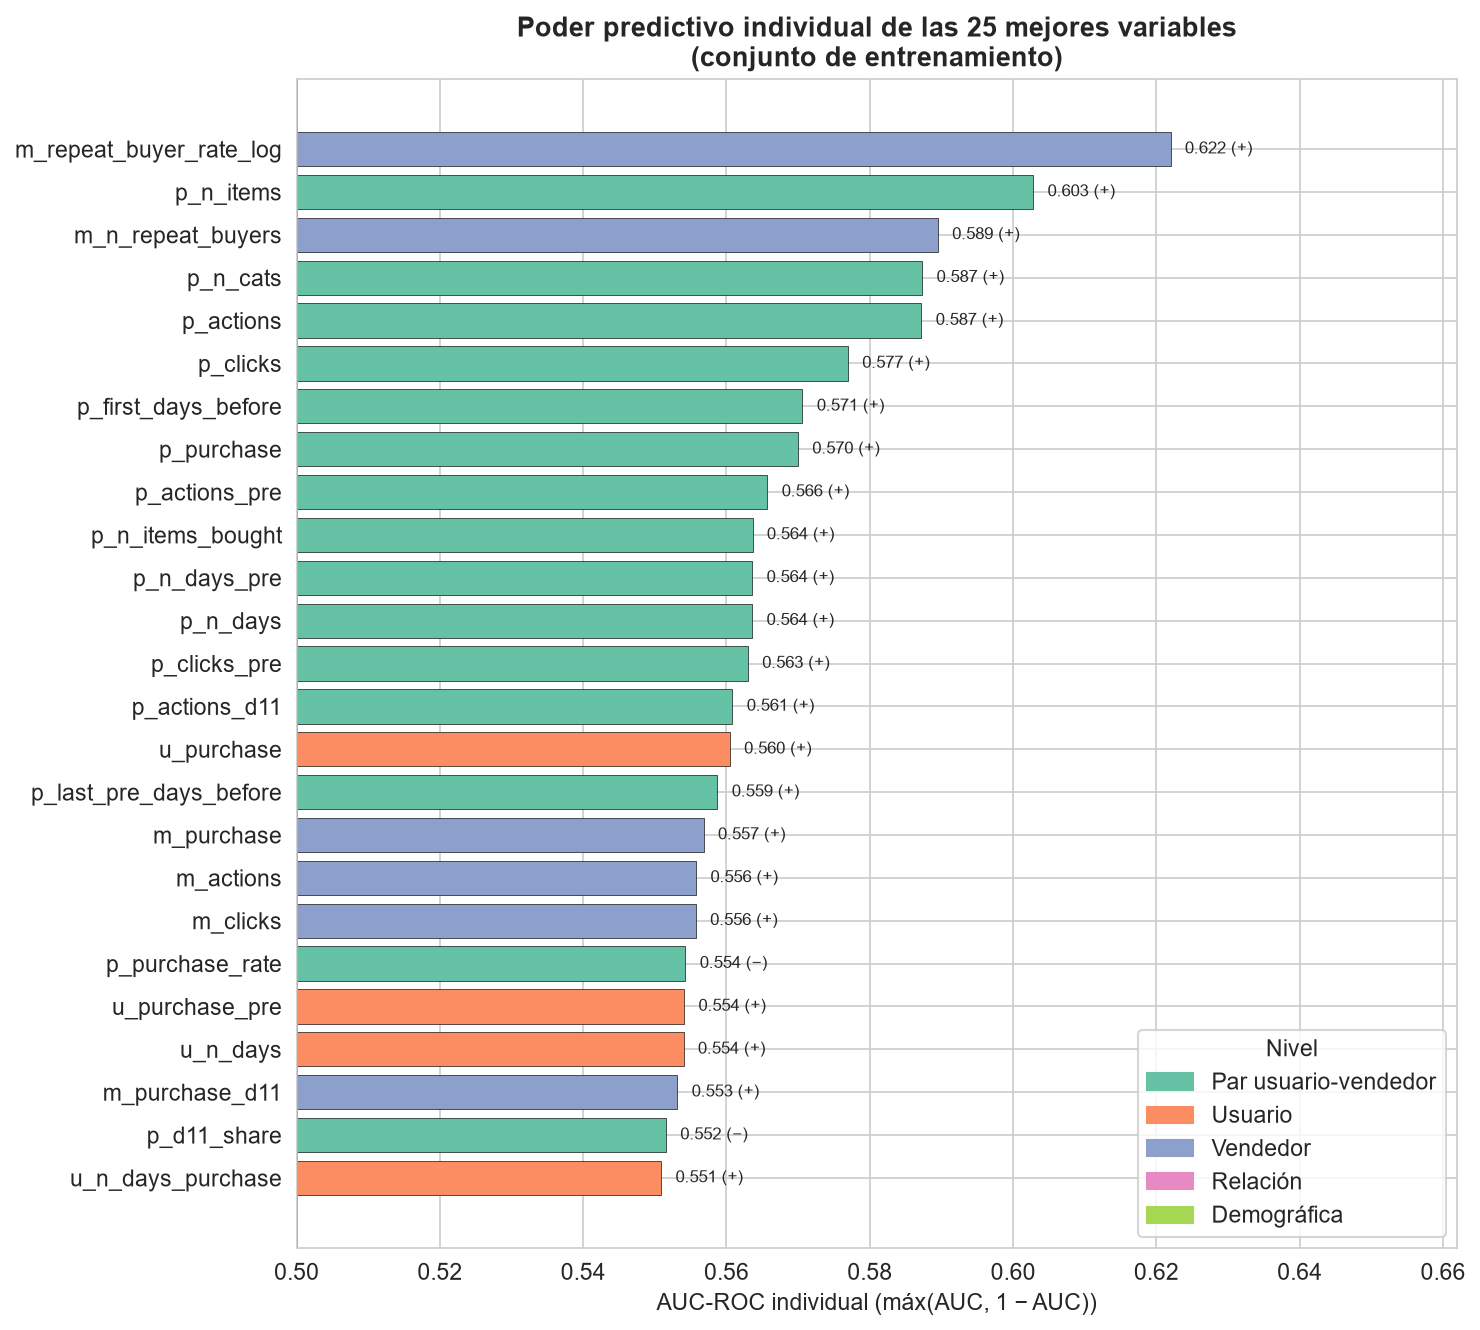

In [13]:
top = auc_ind.head(25).iloc[::-1]
colores_fam = {f: PALETTE[i] for i, f in enumerate(['Par usuario-vendedor', 'Usuario', 'Vendedor',
                                                     'Relación', 'Demográfica'])}

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top['variable'], top['auc_abs'] - 0.5, left=0.5,
        color=[colores_fam[f] for f in top['familia']], edgecolor='black', linewidth=0.3)
for y, (v, d) in enumerate(zip(top['auc_abs'], top['direccion'])):
    ax.text(v + 0.002, y, f'{v:.3f} ({d})', va='center', fontsize=8)
ax.axvline(0.5, color='black', linewidth=0.8)
ax.set_xlim(0.5, top['auc_abs'].max() + 0.04)
ax.set_xlabel('AUC-ROC individual (máx(AUC, 1 − AUC))')
ax.set_title('Poder predictivo individual de las 25 mejores variables\n(conjunto de entrenamiento)',
             fontweight='bold')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colores_fam.values()]
ax.legend(handles, colores_fam.keys(), title='Nivel', loc='lower right')
plt.tight_layout()
fig.savefig(FIG_DIR / '17_auc_individual_variables.png')
plt.show()

### 10.1 Validación de la fidelidad del vendedor calculada sin etiqueta

La mejor variable individual es `m_repeat_buyer_rate_log`. Se verifica que realmente refleja la recompra: se compara, **solo en el conjunto de entrenamiento**, con la tasa real de recompra de cada vendedor y se observa la tasa de recompra por quintil de la variable.

In [14]:
tasa_vendedor = ent.groupby('merchant_id').agg(
    tasa_real=('label', 'mean'), pares=('label', 'size'),
    fidelidad_log=('m_repeat_buyer_rate_log', 'first'))
con_muestra = tasa_vendedor[tasa_vendedor['pares'] >= 30]
print(f"Vendedores con ≥ 30 pares de entrenamiento: {len(con_muestra):,}")
print(f"Correlación de Pearson con la tasa real:  {con_muestra['tasa_real'].corr(con_muestra['fidelidad_log']):.3f}")
print(f"Correlación de Spearman con la tasa real: "
      f"{con_muestra['tasa_real'].corr(con_muestra['fidelidad_log'], method='spearman'):.3f}")

quintiles = ent.groupby(pd.qcut(ent['m_repeat_buyer_rate_log'], 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5']),
                        observed=True)['label'].agg(['mean', 'size'])
quintiles.columns = ['tasa_recompra', 'pares']
print("\nTasa de recompra por quintil de m_repeat_buyer_rate_log:")
display(quintiles.round(4))

print("\nTasa de recompra según actividad previa con el vendedor:")
display(ent.groupby('p_has_pre')['label'].agg(tasa_recompra='mean', pares='size').round(4))

Vendedores con ≥ 30 pares de entrenamiento: 1,323
Correlación de Pearson con la tasa real:  0.511
Correlación de Spearman con la tasa real: 0.425

Tasa de recompra por quintil de m_repeat_buyer_rate_log:


,tasa_recompra,pares
m_repeat_buyer_rate_log,,
Q1,0.0331,41825
Q2,0.0453,41744
Q3,0.0539,42139
Q4,0.0688,42170
Q5,0.1056,40813



Tasa de recompra según actividad previa con el vendedor:


,tasa_recompra,pares
p_has_pre,,
0,0.0512,116814
1,0.0738,91877


**Interpretación**:

- **El vendedor importa tanto como el comprador.** La variable individual más predictiva es `m_repeat_buyer_rate_log` (AUC 0.622): la proporción de compradores del vendedor que le compraron en al menos dos días distintos del registro histórico. Se calcula **sin usar la etiqueta** y aun así se correlaciona con la tasa real de recompra de cada vendedor (Pearson 0.51 en vendedores con al menos 30 pares). La tasa de recompra pasa de 3.3 % en el quintil más bajo a 10.6 % en el más alto. Los vendedores con clientela históricamente fiel retienen más a los compradores del Double 11.
- **Las variables del par siguen siendo las más numerosas entre las útiles**: diversidad (`p_n_items` 0.603, `p_n_cats` 0.587), volumen (`p_actions` 0.587) y **antigüedad de la relación** (`p_first_days_before` 0.571). Los pares con actividad previa al Double 11 recompran más (7.4 %) que los que conocieron al vendedor ese mismo día (5.1 %).
- **El usuario aporta información complementaria** (`u_purchase` 0.560, `u_n_days` 0.554): los usuarios más activos en general recompran algo más.
- **Proporciones con signo negativo**: `p_purchase_rate` y `p_d11_share` (AUC < 0.5) indican que los pares cuya relación con el vendedor se concentra en la compra del Double 11, sin exploración previa, recompran menos: el perfil del comprador "de oferta".
- **La demografía es la familia más débil** (AUC ≤ 0.523), en línea con el EDA.
- Ninguna variable supera un AUC de 0.63 por sí sola, lo que confirma que el modelo necesita combinarlas. La tasa de recompra real del vendedor (*target encoding*), que se calculará fuera de pliegue en el modelado, debería reforzar la señal del vendedor.

## 11. Diccionario de variables y exportación

Se guarda el diccionario de variables y las tablas de modelado en formato parquet (`data/processed/`, excluido de Git por tamaño).

In [15]:
DESCRIPCIONES = {
    'age_range': 'Rango de edad (0 = desconocido, 1 = <18, …, 7 = 50+)',
    'gender': 'Género (0 = femenino, 1 = masculino, 2 = desconocido)',
    'p_clicks': 'Clics del usuario en el vendedor', 'p_cart': 'Adiciones al carrito con el vendedor',
    'p_purchase': 'Compras al vendedor (todas en el Double 11)', 'p_favorite': 'Favoritos con el vendedor',
    'p_actions_d11': 'Interacciones con el vendedor el 11/11', 'p_actions_pre': 'Interacciones con el vendedor antes del 11/11',
    'p_actions': 'Interacciones totales con el vendedor', 'p_n_items': 'Productos distintos del vendedor',
    'p_n_cats': 'Categorías distintas del vendedor', 'p_n_brands': 'Marcas distintas del vendedor',
    'p_n_days': 'Días distintos con actividad con el vendedor', 'p_n_items_bought': 'Productos distintos comprados al vendedor',
    'p_clicks_pre': 'Clics antes del 11/11', 'p_cart_pre': 'Carrito antes del 11/11', 'p_favorite_pre': 'Favoritos antes del 11/11',
    'p_n_days_pre': 'Días con actividad antes del 11/11', 'p_first_days_before': 'Días entre la primera interacción y el 11/11',
    'p_last_pre_days_before': 'Días entre la última interacción previa y el 11/11 (0 = sin actividad previa)',
    'p_has_pre': 'Tuvo actividad con el vendedor antes del 11/11 (0/1)',
    'p_click_rate': 'Clics / interacciones', 'p_cart_rate': 'Carrito / interacciones',
    'p_purchase_rate': 'Compras / interacciones', 'p_favorite_rate': 'Favoritos / interacciones',
    'p_d11_share': 'Proporción de las interacciones con el vendedor que ocurrieron el 11/11',
    'u_clicks': 'Clics del usuario en la plataforma', 'u_cart': 'Carrito del usuario en la plataforma',
    'u_purchase': 'Compras del usuario en la plataforma', 'u_favorite': 'Favoritos del usuario en la plataforma',
    'u_actions_d11': 'Interacciones del usuario el 11/11', 'u_actions': 'Interacciones totales del usuario',
    'u_n_merchants': 'Vendedores distintos con los que interactuó', 'u_n_items': 'Productos distintos',
    'u_n_cats': 'Categorías distintas', 'u_n_brands': 'Marcas distintas', 'u_n_days': 'Días con actividad',
    'u_n_merchants_bought': 'Vendedores distintos a los que compró',
    'u_n_merchants_bought_d11': 'Vendedores distintos a los que compró el 11/11',
    'u_purchase_pre': 'Compras del usuario antes del 11/11', 'u_n_days_purchase': 'Días distintos con compra',
    'u_n_merchants_repeat': 'Vendedores a los que compró en ≥ 2 días distintos (fidelidad histórica)',
    'u_purchase_rate': 'Compras / interacciones del usuario', 'u_d11_share': 'Proporción de la actividad del usuario el 11/11',
    'u_repeat_share': 'Vendedores con recompra / vendedores con compra',
    'm_clicks': 'Clics recibidos por el vendedor', 'm_cart': 'Carrito recibido', 'm_purchase': 'Compras recibidas',
    'm_favorite': 'Favoritos recibidos', 'm_actions': 'Interacciones totales recibidas',
    'm_n_users': 'Usuarios distintos que interactuaron', 'm_n_items': 'Productos distintos del vendedor',
    'm_n_cats': 'Categorías distintas del vendedor', 'm_n_brands': 'Marcas distintas del vendedor',
    'm_n_buyers': 'Compradores distintos', 'm_n_buyers_d11': 'Compradores distintos el 11/11',
    'm_purchase_d11': 'Compras recibidas el 11/11', 'm_n_repeat_buyers': 'Compradores que compraron en ≥ 2 días distintos',
    'm_conversion': 'Compradores / usuarios', 'm_purchase_d11_share': 'Proporción de las compras del vendedor el 11/11',
    'm_repeat_buyer_rate_log': 'Compradores con recompra / compradores (fidelidad sin usar la etiqueta)',
    'x_share_user_actions': 'Interacciones con el vendedor / interacciones del usuario',
    'x_share_user_purchase': 'Compras al vendedor / compras del usuario',
    'x_share_user_merchants_d11': '1 / vendedores a los que el usuario compró el 11/11',
}
faltan = set(FEATURES) - set(DESCRIPCIONES)
assert not faltan, f'Variables sin descripción: {faltan}'

diccionario = pd.DataFrame({
    'variable': FEATURES,
    'nivel': [familia(c) for c in FEATURES],
    'descripcion': [DESCRIPCIONES[c] for c in FEATURES],
}).merge(auc_ind[['variable', 'auc_abs', 'direccion']], on='variable')
diccionario.round(4).to_csv(TAB_DIR / 'diccionario_variables.csv', index=False)
print(diccionario['nivel'].value_counts().to_string())

feat_train.to_parquet(PROCESSED_DIR / 'features_train.parquet', index=False)
feat_test.to_parquet(PROCESSED_DIR / 'features_test.parquet', index=False)
print(f"\n✓ {PROCESSED_DIR / 'features_train.parquet'}: {feat_train.shape}")
print(f"✓ {PROCESSED_DIR / 'features_test.parquet'}: {feat_test.shape}")

nivel
Par usuario-vendedor    24
Usuario                 19
Vendedor                16
Relación                 3
Demográfica              2



✓ C:\Users\Gabriel\Documents\Universidad\semestre8\data\proyecto2\DS-Proyecto2\data\processed\features_train.parquet: (260864, 69)
✓ C:\Users\Gabriel\Documents\Universidad\semestre8\data\proyecto2\DS-Proyecto2\data\processed\features_test.parquet: (261477, 66)
